# Import Libraries

In [1]:
import os
import copy
import random
import warnings
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from PIL import Image
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             accuracy_score, classification_report)

# ── Reproducibility ─────────────────────────────────────────────────────────
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# ── Device ───────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ── AMP GradScaler / autocast (works on both old and new torchvision) ────────
try:
    from torch.amp import GradScaler, autocast          # PyTorch ≥ 2.1
    def make_scaler():
        return GradScaler(device="cuda") if device.type == "cuda" else GradScaler(enabled=False)
    def amp_autocast(enabled):
        return autocast(device_type=device.type, enabled=enabled)
except ImportError:
    from torch.cuda.amp import GradScaler, autocast     # older PyTorch
    def make_scaler():
        return GradScaler(enabled=(device.type == "cuda"))
    def amp_autocast(enabled):
        return autocast(enabled=enabled)


Using device: cuda


In [2]:
# Environment Detection
# Auto-detects Kaggle vs Colab vs Local and sets WORKING_DIR for all outputs.

import os

ON_KAGGLE = os.path.exists("/kaggle/working")
ON_COLAB  = False

try:
    import google.colab          # noqa: F401
    from google.colab import drive
    drive.mount("/content/drive")
    ON_COLAB = True
except Exception:
    pass

if ON_KAGGLE:
    WORKING_DIR = "/kaggle/working"
elif ON_COLAB:
    WORKING_DIR = "/content"
else:
    WORKING_DIR = os.path.join(os.getcwd(), "lemon_working")

os.makedirs(WORKING_DIR, exist_ok=True)
print(f"Environment : {'Kaggle' if ON_KAGGLE else 'Colab' if ON_COLAB else 'Local'}")
print(f"WORKING_DIR : {WORKING_DIR}")

# Dataset Path
# UPDATE the first Kaggle path to match your dataset slug if needed.
# On Kaggle: check what appears under /kaggle/input/ in the file browser.
candidate_paths = [
    "/kaggle/input/lemon-leaf-disease-dataset/Original Dataset/Original Dataset",
    "/kaggle/input/lemon-leaf-disease-dataset/Augmented Dataset/Aumented Dataset",
    "/content/drive/MyDrive/Lemon Leaf Disease Detection/Data/Lemon Leaf Disease Dataset",
    os.path.join(os.getcwd(), "data"),
]

data_dir = None
for p in candidate_paths:
    if os.path.exists(p):
        data_dir = p
        break

if data_dir is None:
    raise FileNotFoundError(
        "Dataset not found. Update `candidate_paths` with your actual dataset path.\n"
        "On Kaggle: check /kaggle/input/<your-dataset-slug>/"
    )

print(f"Dataset path: {data_dir}")


Google Drive mount skipped.
Using dataset path: /kaggle/input/lemon-leaf-disease-dataset/Original Dataset/Original Dataset


In [3]:
import os
classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
classes.sort()
print(f"Number of classes: {len(classes)}\n")

Number of classes: 9



In [4]:
# count images per class
class_counts = {}
total_images = 0

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    img_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    count = len(img_files)
    class_counts[cls] = count
    total_images += count

print(f"Total images: {total_images}")
print("Class distribution:")
for cls, count in class_counts.items():
    print(f"{cls:20s} : {count}")

Total images: 1354
Class distribution:
Anthracnose          : 100
Bacterial Blight     : 105
Citrus Canker        : 178
Curl Virus           : 115
Deficiency Leaf      : 193
Dry Leaf             : 186
Healthy Leaf         : 210
Sooty Mould          : 153
Spider Mites         : 114


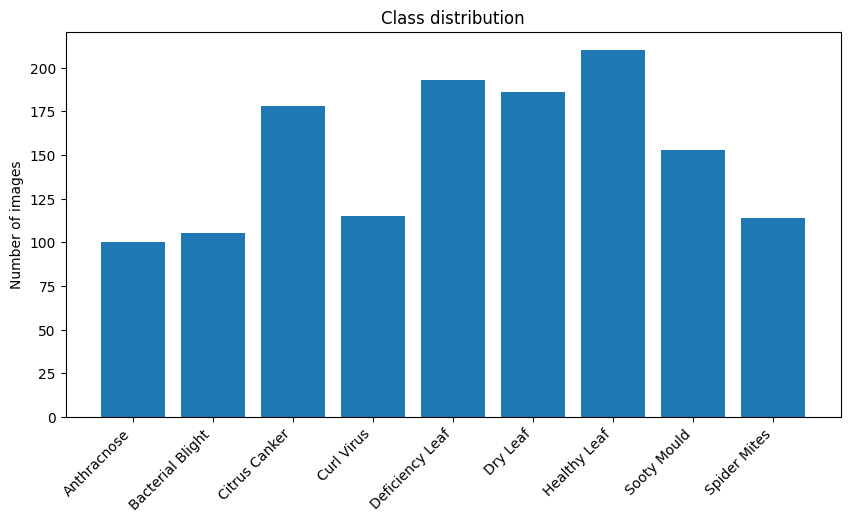

In [5]:
# --- visualize ---
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of images")
plt.title("Class distribution")
plt.show()

In [6]:
from PIL import Image

image_sizes = []
for cls in classes:
    for img_file in os.listdir(os.path.join(data_dir, cls)):
        img = Image.open(os.path.join(data_dir, cls, img_file))
        image_sizes.append(img.size)

print(set(image_sizes)) 

{(1000, 1000)}


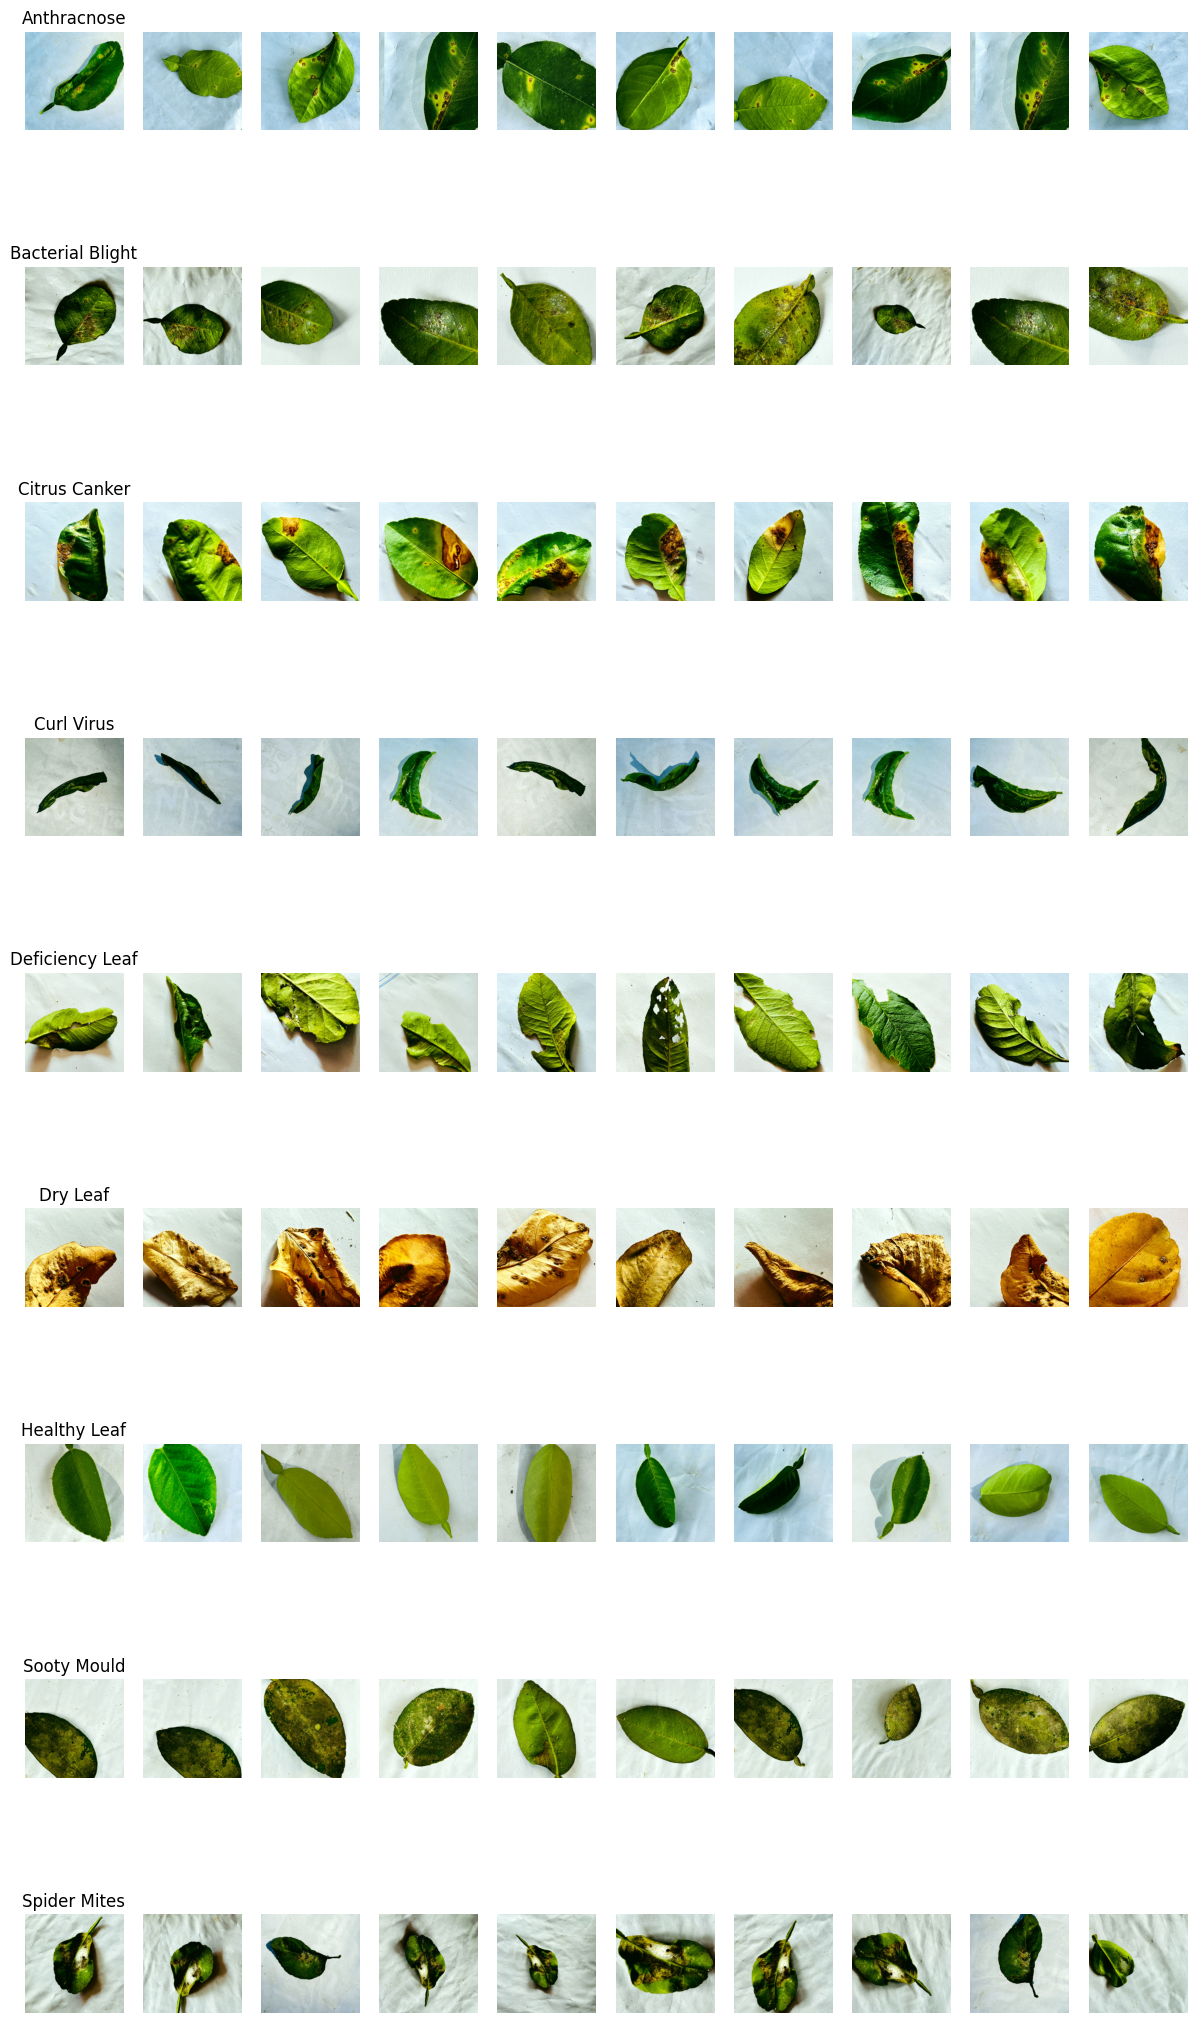

In [7]:
import random
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(classes), 10, figsize=(15, len(classes) * 3))
for i, cls in enumerate(classes):
    class_dir = os.path.join(data_dir, cls)
    for j in range(10):
        img_path = os.path.join(class_dir, random.choice(os.listdir(class_dir)))
        img = Image.open(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_title(cls)
plt.show()

In [8]:
corrupted_images = []
for cls in classes:
    for img_file in os.listdir(os.path.join(data_dir, cls)):
        try:
            img = Image.open(os.path.join(data_dir, cls, img_file))
            img.verify()  # Check for corruption
        except (IOError, SyntaxError):
            corrupted_images.append(img_file)

print("Corrupted Images:", corrupted_images)

Corrupted Images: []


In [9]:
# Training Configuration and Transforms
IMG_SIZE            = 224
BATCH_SIZE          = 16
ENSEMBLE_BATCH_SIZE = 8
NUM_WORKERS         = 2
BASE_EPOCHS         = 10      # increase to 15-20 for best accuracy
ENSEMBLE_EPOCHS     = 10
BASE_LR             = 1e-4
ENSEMBLE_LR         = 5e-2
PATIENCE            = 3

# Output directories (auto-set by environment detection in Cell 2)
SAVE_DIR   = os.path.join(WORKING_DIR, "lemon_checkpoints")
EXPORT_DIR = os.path.join(WORKING_DIR, "fastapi_artifacts")

os.makedirs(SAVE_DIR,   exist_ok=True)
os.makedirs(EXPORT_DIR, exist_ok=True)

print(f"Checkpoint dir : {SAVE_DIR}")
print(f"Export dir     : {EXPORT_DIR}")

# ImageNet normalisation
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])


In [10]:
# ------------------------------------------
# Build Dataset and Stratified Splits
# ------------------------------------------
base_dataset = datasets.ImageFolder(root=data_dir)
num_classes = len(base_dataset.classes)
class_names = base_dataset.classes
targets = np.array(base_dataset.targets)
indices = np.arange(len(targets))

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Total images:", len(indices))

# 70% base-train, 10% base-val, 10% ensemble-train, 10% test
try:
    train_idx, temp_idx = train_test_split(
        indices, test_size=0.30, stratify=targets, random_state=42
    )

    temp_targets = targets[temp_idx]
    base_val_idx, rest_idx = train_test_split(
        temp_idx, test_size=2/3, stratify=temp_targets, random_state=42
    )

    rest_targets = targets[rest_idx]
    ensemble_train_idx, test_idx = train_test_split(
        rest_idx, test_size=0.5, stratify=rest_targets, random_state=42
    )
except ValueError as e:
    warnings.warn(f"Stratified split failed: {e}. Falling back to random split.")
    shuffled = np.random.permutation(indices)
    n = len(shuffled)
    n_train = int(0.7 * n)
    n_base_val = int(0.1 * n)
    n_ensemble = int(0.1 * n)

    train_idx = shuffled[:n_train]
    base_val_idx = shuffled[n_train:n_train+n_base_val]
    ensemble_train_idx = shuffled[n_train+n_base_val:n_train+n_base_val+n_ensemble]
    test_idx = shuffled[n_train+n_base_val+n_ensemble:]

print("Base train size:", len(train_idx))
print("Base val size:", len(base_val_idx))
print("Ensemble train size:", len(ensemble_train_idx))
print("Test size:", len(test_idx))

train_full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
eval_full_dataset = datasets.ImageFolder(root=data_dir, transform=eval_transform)

train_dataset = Subset(train_full_dataset, train_idx)
base_val_dataset = Subset(eval_full_dataset, base_val_idx)
ensemble_train_dataset = Subset(eval_full_dataset, ensemble_train_idx)
test_dataset = Subset(eval_full_dataset, test_idx)

Classes: ['Anthracnose', 'Bacterial Blight', 'Citrus Canker', 'Curl Virus', 'Deficiency Leaf', 'Dry Leaf', 'Healthy Leaf', 'Sooty Mould', 'Spider Mites']
Number of classes: 9
Total images: 1354
Base train size: 947
Base val size: 135
Ensemble train size: 136
Test size: 136


In [11]:
# ------------------------------------------
# DataLoaders and Loss Function
# ------------------------------------------
pin_memory = device.type == "cuda"

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=pin_memory
)

base_val_loader = DataLoader(
    base_val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin_memory
)

ensemble_train_loader = DataLoader(
    ensemble_train_dataset, batch_size=ENSEMBLE_BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset, batch_size=ENSEMBLE_BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin_memory
)

# Class-weighted loss for imbalance handling
train_targets = targets[train_idx]
class_counts = np.bincount(train_targets, minlength=num_classes)
class_counts = np.maximum(class_counts, 1)
class_weights = len(train_targets) / (num_classes * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

print("Class counts (base train):", class_counts.tolist())
print("Class weights:", class_weights.detach().cpu().numpy())

Class counts (base train): [70, 73, 125, 80, 135, 130, 147, 107, 80]
Class weights: [1.5031747  1.4414003  0.8417778  1.3152778  0.7794239  0.8094017
 0.7157974  0.98338526 1.3152778 ]


In [12]:
## Define Base Models

# ──────────────────────────────────────────────────────────────────────────────
# Build a pretrained model with a new classification head for num_classes.
# Handles:
#   • resnet50        – model.fc
#   • efficientnet_b0 – model.classifier[-1]
#   • mobilenet_v2    – model.classifier[-1]  (was broken: needs index -1)
#   • densenet121     – model.classifier
# Falls back to pretrained=True on older torchvision that lacks Weights enums.
# ──────────────────────────────────────────────────────────────────────────────

def build_pretrained_model(model_name: str, num_classes: int) -> nn.Module:
    """Load a pretrained backbone and attach a fresh classification head."""
    try:
        _W = {
            "resnet50":       models.ResNet50_Weights.DEFAULT,
            "efficientnet_b0": models.EfficientNet_B0_Weights.DEFAULT,
            "mobilenet_v2":   models.MobileNet_V2_Weights.DEFAULT,
            "densenet121":    models.DenseNet121_Weights.DEFAULT,
        }
        if model_name not in _W:
            raise ValueError(f"Unsupported model: {model_name}")
        model = getattr(models, model_name)(weights=_W[model_name])
    except AttributeError:
        # Older torchvision (< 0.13) – fall back to pretrained flag
        warnings.warn(f"Weights enum unavailable; using pretrained=True for {model_name}")
        model = getattr(models, model_name)(pretrained=True)

    # ── Replace the final layer ───────────────────────────────────────────────
    if model_name == "resnet50":
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == "efficientnet_b0":
        # classifier is Sequential([Dropout, Linear])
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif model_name == "mobilenet_v2":
        # classifier is Sequential([Dropout, Linear])
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif model_name == "densenet121":
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    return model.to(device)

model_names = ["resnet50", "efficientnet_b0", "mobilenet_v2", "densenet121"]
print("Base models:", model_names)


Base models: ['resnet50', 'efficientnet_b0', 'mobilenet_v2', 'densenet121']


In [13]:
## Training Utilities

# ──────────────────────────────────────────────────────────────────────────────
# run_epoch  : one pass over a DataLoader (train OR eval).
# train_single_model : full training loop with AMP, LR scheduling,
#                      early stopping, and best-checkpoint saving.
# ──────────────────────────────────────────────────────────────────────────────

def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    """Run one epoch.  Pass optimizer+scaler for training; None for eval."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, total_correct, total_samples = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with amp_autocast(enabled=(device.type == "cuda")):
                outputs = model(images)
                loss    = criterion(outputs, labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        preds         = outputs.argmax(dim=1)
        total_loss    += loss.item() * images.size(0)
        total_correct += (preds == labels).sum().item()
        total_samples += images.size(0)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    return (total_loss / total_samples,
            total_correct / total_samples,
            np.array(all_labels),
            np.array(all_preds))


def train_single_model(model_name, train_loader, val_loader, criterion,
                       epochs=10, lr=1e-4, patience=3):
    """
    1. Build pretrained model with new head (all parameters trainable).
    2. Train with AdamW + ReduceLROnPlateau + AMP.
    3. Early-stop on val accuracy; save best checkpoint.
    4. Return (model_with_best_weights, checkpoint_path).
    """
    model     = build_pretrained_model(model_name, num_classes)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode="min", factor=0.5, patience=1, verbose=False)
    scaler    = make_scaler()

    best_val_acc = 0.0
    best_state   = copy.deepcopy(model.state_dict())
    wait         = 0
    ckpt_path    = os.path.join(SAVE_DIR, f"{model_name}_best.pth")

    print("\n" + "=" * 80)
    print(f"  Training: {model_name}  (all layers, {epochs} epochs max, patience={patience})")
    print("=" * 80)

    for epoch in range(epochs):
        tr_loss, tr_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer, scaler)
        vl_loss, vl_acc, _, _ = run_epoch(model, val_loader,   criterion)
        scheduler.step(vl_loss)

        lr_now = optimizer.param_groups[0]["lr"]
        print(f"  [{model_name}] Epoch {epoch+1:>2}/{epochs} | "
              f"LR {lr_now:.2e} | "
              f"Train  Loss {tr_loss:.4f}  Acc {tr_acc:.4f} | "
              f"Val  Loss {vl_loss:.4f}  Acc {vl_acc:.4f}",
              end="")

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = copy.deepcopy(model.state_dict())
            torch.save(best_state, ckpt_path)
            wait = 0
            print("  ← best ✓")
        else:
            wait += 1
            print(f"  (no improvement {wait}/{patience})")
            if wait >= patience:
                print(f"  Early stopping at epoch {epoch+1}.")
                break

    model.load_state_dict(best_state)
    print(f"  {model_name}: best val acc = {best_val_acc:.4f} | checkpoint: {ckpt_path}")
    return model, ckpt_path


In [14]:
## Train Base Models and Load Best Checkpoints

# ──────────────────────────────────────────────────────────────────────────────
# Step 1 – Train each base model individually (full fine-tuning).
# Step 2 – Reload each model from its best checkpoint.
# Step 3 – Freeze all parameters so only ensemble weights will be learned.
# ──────────────────────────────────────────────────────────────────────────────

checkpoint_paths = {}

# ── Step 1 & 2 : train, peek at test set, collect checkpoint paths ────────────
for name in model_names:
    model, ckpt_path = train_single_model(
        model_name   = name,
        train_loader = train_loader,
        val_loader   = base_val_loader,
        criterion    = criterion,
        epochs       = BASE_EPOCHS,
        lr           = BASE_LR,
        patience     = PATIENCE,
    )
    checkpoint_paths[name] = ckpt_path

    # Quick individual test evaluation (informational only)
    ts_loss, ts_acc, _, _ = run_epoch(model, test_loader, criterion)
    print(f"  [{name}] standalone test → Loss {ts_loss:.4f}  Acc {ts_acc:.4f}")

    # Free GPU memory before loading the next base model
    del model
    torch.cuda.empty_cache()


# ── Helper : reload a saved checkpoint and freeze all parameters ──────────────
def load_trained_model(model_name: str, ckpt_path: str, num_classes: int) -> nn.Module:
    """
    Rebuild the architecture, load the best-checkpoint weights,
    then freeze every parameter so only ensemble.raw_weights is trainable.
    """
    model = build_pretrained_model(model_name, num_classes)
    state = torch.load(ckpt_path, map_location=device, weights_only=True)
    model.load_state_dict(state)

    for param in model.parameters():
        param.requires_grad = False          # ← FREEZE

    model.eval()
    return model


# ── Step 3 : load all four frozen models ready for ensemble training ──────────
print("\n" + "=" * 80)
print("  Reloading best checkpoints and freezing base models …")
print("=" * 80)

trained_models = [
    load_trained_model(name, checkpoint_paths[name], num_classes)
    for name in model_names
]

for name, m in zip(model_names, trained_models):
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"  {name}: trainable params after freeze = {trainable}  (expected 0)")

print("\nAll base models frozen. Ready to train ensemble weights.")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s]



  Training: resnet50  (all layers, 10 epochs max, patience=3)


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  [resnet50] Epoch  1/10 | LR 1.00e-04 | Train  Loss 1.5552  Acc 0.6769 | Val  Loss 0.4640  Acc 0.9852  ← best ✓
  [resnet50] Epoch  2/10 | LR 1.00e-04 | Train  Loss 0.5172  Acc 0.9409 | Val  Loss 0.3682  Acc 0.9852  (no improvement 1/3)
  [resnet50] Epoch  3/10 | LR 1.00e-04 | Train  Loss 0.4224  Acc 0.9620 | Val  Loss 0.3504  Acc 0.9852  (no improvement 2/3)
  [resnet50] Epoch  4/10 | LR 1.00e-04 | Train  Loss 0.3976  Acc 0.9778 | Val  Loss 0.3431  Acc 0.9926  ← best ✓
  [resnet50] Epoch  5/10 | LR 1.00e-04 | Train  Loss 0.3702  Acc 0.9820 | Val  Loss 0.3200  Acc 1.0000  ← best ✓
  [resnet50] Epoch  6/10 | LR 1.00e-04 | Train  Loss 0.3635  Acc 0.9820 | Val  Loss 0.3525  Acc 0.9852  (no improvement 1/3)
  [resnet50] Epoch  7/10 | LR 1.00e-04 | Train  Loss 0.3432  Acc 0.9916 | Val  Loss 0.3157  Acc 0.9926  (no improvement 2/3)
  [resnet50] Epoch  8/10 | LR 1.00e-04 | Train  Loss 0.3513  Acc 0.9852 | Val  Loss 0.3154  Acc 0.9926  (no improvement 3/3)
  Early stopping at epoch 8.
  resne

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 161MB/s]


...

  [efficientnet_b0] standalone test → Loss 0.4456  Acc 0.9632


100%|██████████| 13.6M/13.6M [00:00<00:00, 144MB/s]



  Training: mobilenet_v2  (all layers, 10 epochs max, patience=3)
  [mobilenet_v2] Epoch  1/10 | LR 1.00e-04 | Train  Loss 1.8636  Acc 0.4593 | Val  Loss 1.2155  Acc 0.9037  ← best ✓
  [mobilenet_v2] Epoch  2/10 | LR 1.00e-04 | Train  Loss 1.0477  Acc 0.8733 | Val  Loss 0.5356  Acc 1.0000  ← best ✓
  [mobilenet_v2] Epoch  3/10 | LR 1.00e-04 | Train  Loss 0.5999  Acc 0.9335 | Val  Loss 0.3850  Acc 0.9926  (no improvement 1/3)
  [mobilenet_v2] Epoch  4/10 | LR 1.00e-04 | Train  Loss 0.4920  Acc 0.9546 | Val  Loss 0.3446  Acc 1.0000  (no improvement 2/3)
  [mobilenet_v2] Epoch  5/10 | LR 1.00e-04 | Train  Loss 0.4182  Acc 0.9768 | Val  Loss 0.3367  Acc 1.0000  (no improvement 3/3)
  Early stopping at epoch 5.
  mobilenet_v2: best val acc = 1.0000 | checkpoint: /content/lemon_ensemble_checkpoints/mobilenet_v2_best.pth
  [mobilenet_v2] standalone test → Loss 0.7125  Acc 0.9191


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 159MB/s]



  Training: densenet121  (all layers, 10 epochs max, patience=3)
  [densenet121] Epoch  1/10 | LR 1.00e-04 | Train  Loss 1.1657  Acc 0.7561 | Val  Loss 0.4428  Acc 0.9852  ← best ✓
  [densenet121] Epoch  2/10 | LR 1.00e-04 | Train  Loss 0.4750  Acc 0.9567 | Val  Loss 0.3486  Acc 1.0000  ← best ✓
  [densenet121] Epoch  3/10 | LR 1.00e-04 | Train  Loss 0.4125  Acc 0.9757 | Val  Loss 0.3388  Acc 1.0000  (no improvement 1/3)
  [densenet121] Epoch  4/10 | LR 1.00e-04 | Train  Loss 0.3822  Acc 0.9810 | Val  Loss 0.3287  Acc 1.0000  (no improvement 2/3)
  [densenet121] Epoch  5/10 | LR 1.00e-04 | Train  Loss 0.3505  Acc 0.9905 | Val  Loss 0.3292  Acc 0.9926  (no improvement 3/3)
  Early stopping at epoch 5.
  densenet121: best val acc = 1.0000 | checkpoint: /content/lemon_ensemble_checkpoints/densenet121_best.pth
  [densenet121] standalone test → Loss 0.4569  Acc 0.9485

  Reloading best checkpoints and freezing base models …
  resnet50: trainable params after freeze = 0  (expected 0)
  effi

In [15]:
## Weighted Ensemble and Evaluation

# ──────────────────────────────────────────────────────────────────────────────
# WeightedEnsemble
#   • raw_weights (one per base model) are the only trainable parameters.
#   • forward: stack [N_models, B, C] → softmax-weighted sum → [B, C]
#   • Bug fix: previous code used .view(-1, 1, 1) which broadcasts to
#     shape [N_models, 1, 1]; correct broadcast shape is [N_models, 1, 1]
#     when outputs is [N_models, B, C].  Kept here but clarified.
# ──────────────────────────────────────────────────────────────────────────────

class WeightedEnsemble(nn.Module):
    def __init__(self, base_models):
        super().__init__()
        self.models     = nn.ModuleList(base_models)   # frozen
        # raw_weights are the ONLY learnable parameters
        self.raw_weights = nn.Parameter(torch.zeros(len(base_models)))

    def forward(self, x):
        # outputs: shape [N_models, B, C]
        with torch.no_grad():                          # base models are frozen
            outputs = torch.stack([m(x) for m in self.models], dim=0)
        # weights: shape [N_models, 1, 1]  →  broadcast over (B, C)
        weights = torch.softmax(self.raw_weights, dim=0).view(-1, 1, 1)
        return (outputs * weights).sum(dim=0)          # [B, C]

    def get_weights(self):
        return torch.softmax(self.raw_weights.detach().cpu(), dim=0).numpy()


# ──────────────────────────────────────────────────────────────────────────────
# train_ensemble_weights
#   Only ensemble.raw_weights receive gradients.
#   Base-model parameters are already frozen (requires_grad=False).
# ──────────────────────────────────────────────────────────────────────────────
def train_ensemble_weights(ensemble, loader, criterion, max_epochs=10):
    # Sanity-check: only raw_weights should be trainable
    trainable = [n for n, p in ensemble.named_parameters() if p.requires_grad]
    print(f"  Trainable parameters in ensemble: {trainable}")
    assert trainable == ["raw_weights"], (
        "Base model parameters are NOT frozen! "
        "Call load_trained_model() before building WeightedEnsemble."
    )

    optimizer = optim.Adam([ensemble.raw_weights], lr=ENSEMBLE_LR)

    print("\n" + "=" * 80)
    print("  Training ensemble weights (base models frozen)")
    print("=" * 80)

    for epoch in range(max_epochs):
        ensemble.train()                   # enables grad on raw_weights
        total_loss, correct, total = 0.0, 0, 0

        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = ensemble(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds       = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += images.size(0)

        w = ensemble.get_weights()
        w_str = "  ".join(f"{n}:{v:.4f}" for n, v in zip(model_names, w))
        print(f"  Ensemble Epoch {epoch+1:>2}/{max_epochs} | "
              f"Loss {total_loss/total:.4f} | Acc {correct/total:.4f} | "
              f"Weights → {w_str}")

    return ensemble


# ──────────────────────────────────────────────────────────────────────────────
# evaluate_model : accuracy, precision, recall, F1, full classification report
# ──────────────────────────────────────────────────────────────────────────────
def evaluate_model(model, loader, title="Model"):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds   = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score   (y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score       (y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n{'='*60}")
    print(f"  [{title}]")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}  (weighted)")
    print(f"  Recall    : {rec:.4f}  (weighted)")
    print(f"  F1-score  : {f1:.4f}  (weighted)")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred,
                                target_names=class_names,
                                digits=4, zero_division=0))
    return y_true, y_pred


# ── Evaluate individual base models ──────────────────────────────────────────
print("\nIndividual base-model evaluation on test set:")
for name, model in zip(model_names, trained_models):
    evaluate_model(model, test_loader, title=name)

# ── Build ensemble, train weights, then evaluate ──────────────────────────────
ensemble_model = WeightedEnsemble(trained_models).to(device)

ensemble_model = train_ensemble_weights(
    ensemble_model,
    ensemble_train_loader,
    criterion,
    max_epochs=ENSEMBLE_EPOCHS,
)

evaluate_model(ensemble_model, test_loader, title="Final Weighted Ensemble")



Individual base-model evaluation on test set:

  [resnet50]
  Accuracy  : 0.9485
  Precision : 0.9553  (weighted)
  Recall    : 0.9485  (weighted)
  F1-score  : 0.9488  (weighted)
                  precision    recall  f1-score   support

     Anthracnose     0.9000    0.9000    0.9000        10
Bacterial Blight     0.7692    1.0000    0.8696        10
   Citrus Canker     0.9444    1.0000    0.9714        17
      Curl Virus     1.0000    0.9167    0.9565        12
 Deficiency Leaf     1.0000    1.0000    1.0000        20
        Dry Leaf     1.0000    0.9474    0.9730        19
    Healthy Leaf     0.9130    1.0000    0.9545        21
     Sooty Mould     1.0000    0.8125    0.8966        16
    Spider Mites     1.0000    0.9091    0.9524        11

        accuracy                         0.9485       136
       macro avg     0.9474    0.9428    0.9416       136
    weighted avg     0.9553    0.9485    0.9488       136


  [efficientnet_b0]
  Accuracy  : 0.9632
  Precision : 0.9670

(array([1, 5, 3, 5, 6, 5, 7, 7, 6, 2, 0, 6, 3, 5, 5, 6, 1, 6, 7, 4, 4, 7,
        7, 2, 3, 0, 7, 3, 1, 8, 7, 3, 5, 8, 7, 1, 2, 5, 2, 0, 3, 2, 4, 0,
        7, 5, 8, 8, 7, 2, 5, 4, 6, 0, 5, 2, 6, 2, 2, 3, 2, 5, 5, 5, 5, 6,
        7, 2, 4, 8, 5, 2, 4, 8, 4, 6, 4, 4, 8, 5, 3, 2, 5, 6, 0, 1, 0, 2,
        4, 7, 8, 6, 8, 1, 1, 2, 1, 1, 7, 3, 4, 6, 3, 6, 6, 0, 4, 6, 0, 7,
        6, 7, 4, 0, 6, 6, 4, 6, 4, 1, 5, 3, 4, 3, 8, 8, 4, 2, 7, 4, 4, 5,
        2, 4, 6, 6]),
 array([1, 5, 3, 5, 6, 5, 7, 7, 6, 2, 0, 6, 3, 5, 5, 6, 1, 6, 7, 4, 4, 7,
        7, 2, 3, 0, 7, 3, 1, 8, 7, 0, 5, 8, 0, 1, 2, 5, 2, 0, 3, 2, 4, 0,
        7, 5, 8, 8, 7, 2, 5, 4, 6, 0, 5, 2, 6, 2, 2, 3, 2, 5, 5, 5, 5, 6,
        7, 2, 4, 8, 5, 2, 4, 8, 4, 6, 4, 4, 8, 5, 3, 2, 5, 6, 0, 1, 0, 2,
        4, 7, 1, 6, 8, 1, 1, 2, 1, 1, 7, 3, 4, 6, 3, 6, 6, 0, 4, 6, 0, 6,
        6, 7, 4, 0, 6, 6, 4, 6, 4, 1, 5, 3, 4, 3, 8, 8, 4, 2, 7, 4, 4, 2,
        2, 4, 6, 6]))

In [16]:
# Final normalized ensemble weights
print("\nFinal normalized ensemble weights:")
print("-" * 40)
for name, weight in zip(model_names, ensemble_model.get_weights()):
    bar = chr(9608) * int(weight * 40)
    print(f"  {name:<20s}  {weight:.4f}  {bar}")



Final normalized ensemble weights:
----------------------------------------
  resnet50              0.7270  █████████████████████████████
  efficientnet_b0       0.0621  ██
  mobilenet_v2          0.0120  
  densenet121           0.1990  ███████


In [ ]:
# File contents stored as strings so the export cell can write them to disk.
INFERENCE_PY_CODE   = '"""\ninference.py - Lemon Leaf Disease Ensemble Inference\nLoads ensemble_bundle.pth and runs prediction on a single PIL image.\n\nUsage:\n    from inference import load_model, predict\n    model, meta = load_model("ensemble_bundle.pth")\n    result = predict(model, meta, image)   # image: PIL.Image.Image\n"""\n\nimport torch\nimport torch.nn as nn\nfrom torchvision import models, transforms\nfrom PIL import Image\n\n\nDEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n\n\ndef _build_base_model(model_name: str, num_classes: int) -> nn.Module:\n    """Rebuild architecture with no pretrained weights (loaded from bundle)."""\n    try:\n        m = getattr(models, model_name)(weights=None)\n    except TypeError:\n        m = getattr(models, model_name)(pretrained=False)\n\n    if model_name == "resnet50":\n        m.fc = nn.Linear(m.fc.in_features, num_classes)\n    elif model_name in ("efficientnet_b0", "mobilenet_v2"):\n        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)\n    elif model_name == "densenet121":\n        m.classifier = nn.Linear(m.classifier.in_features, num_classes)\n    return m\n\n\nclass WeightedEnsemble(nn.Module):\n    def __init__(self, base_models, raw_weights_tensor):\n        super().__init__()\n        self.models      = nn.ModuleList(base_models)\n        self.raw_weights = nn.Parameter(raw_weights_tensor)\n\n    def forward(self, x):\n        with torch.no_grad():\n            outputs = torch.stack([m(x) for m in self.models], dim=0)\n        weights = torch.softmax(self.raw_weights, dim=0).view(-1, 1, 1)\n        return (outputs * weights).sum(dim=0)\n\n    def get_weights(self):\n        return torch.softmax(self.raw_weights.detach().cpu(), dim=0).tolist()\n\n\ndef load_model(bundle_path: str = "ensemble_bundle.pth"):\n    """\n    Load the ensemble from a saved bundle.\n    Returns (model, meta) where meta has class_names, img_size, mean, std.\n    """\n    bundle = torch.load(bundle_path, map_location=DEVICE, weights_only=False)\n\n    num_classes = bundle["num_classes"]\n    model_names = bundle["model_names"]\n    base_states = bundle["base_model_states"]\n    raw_weights = bundle["ensemble_raw_weights"].to(DEVICE)\n\n    base_models = []\n    for name in model_names:\n        m = _build_base_model(name, num_classes).to(DEVICE)\n        m.load_state_dict(base_states[name])\n        for p in m.parameters():\n            p.requires_grad = False\n        m.eval()\n        base_models.append(m)\n\n    ensemble = WeightedEnsemble(base_models, raw_weights).to(DEVICE)\n    ensemble.eval()\n\n    meta = {k: bundle[k] for k in ("class_names", "img_size", "mean", "std", "model_names")}\n    return ensemble, meta\n\n\ndef predict(model: nn.Module, meta: dict, image: Image.Image) -> dict:\n    """\n    Run inference on a single PIL image.\n    Returns dict with predicted_class, confidence, class_probabilities.\n    """\n    tf = transforms.Compose([\n        transforms.Resize((meta["img_size"], meta["img_size"])),\n        transforms.ToTensor(),\n        transforms.Normalize(meta["mean"], meta["std"]),\n    ])\n\n    tensor = tf(image.convert("RGB")).unsqueeze(0).to(DEVICE)\n\n    with torch.no_grad():\n        logits = model(tensor)\n        probs  = torch.softmax(logits, dim=1).squeeze().cpu()\n\n    top_idx  = probs.argmax().item()\n    top_prob = probs[top_idx].item()\n\n    return {\n        "predicted_class"     : meta["class_names"][top_idx],\n        "confidence"          : round(top_prob, 4),\n        "class_probabilities" : {\n            cls: round(probs[i].item(), 4)\n            for i, cls in enumerate(meta["class_names"])\n        },\n    }\n'
APP_PY_CODE         = '"""\napp.py - FastAPI server for Lemon Leaf Disease Classification\n\nRun with:\n    uvicorn app:app --host 0.0.0.0 --port 8000\n\nTest:\n    curl http://localhost:8000/health\n    curl -X POST http://localhost:8000/predict -F "file=@leaf.jpg"\n"""\n\nfrom contextlib import asynccontextmanager\nfrom pathlib import Path\nimport io\n\nfrom fastapi import FastAPI, File, UploadFile, HTTPException\nfrom fastapi.responses import JSONResponse\nfrom PIL import Image\n\nfrom inference import load_model, predict as run_predict\n\nMODEL = None\nMETA  = None\nBUNDLE_PATH = Path(__file__).parent / "ensemble_bundle.pth"\n\n\n@asynccontextmanager\nasync def lifespan(app: FastAPI):\n    global MODEL, META\n    print(f"Loading model from {BUNDLE_PATH} ...")\n    MODEL, META = load_model(str(BUNDLE_PATH))\n    print(f"Model ready. Classes: {META[\'class_names\']}")\n    yield\n\n\napp = FastAPI(\n    title="Lemon Leaf Disease Classifier",\n    description="Weighted ensemble of ResNet50 / EfficientNet-B0 / MobileNetV2 / DenseNet121",\n    version="1.0.0",\n    lifespan=lifespan,\n)\n\n\n@app.get("/")\ndef root():\n    return {"status": "ok", "model": "lemon-leaf-ensemble", "classes": META["class_names"]}\n\n\n@app.get("/health")\ndef health():\n    return {"status": "healthy", "model_loaded": MODEL is not None}\n\n\n@app.post("/predict")\nasync def predict_endpoint(file: UploadFile = File(...)):\n    if not file.content_type.startswith("image/"):\n        raise HTTPException(status_code=400, detail="Uploaded file must be an image.")\n\n    try:\n        contents = await file.read()\n        image    = Image.open(io.BytesIO(contents)).convert("RGB")\n    except Exception as exc:\n        raise HTTPException(status_code=400, detail=f"Could not read image: {exc}")\n\n    result = run_predict(MODEL, META, image)\n    return JSONResponse(content=result)\n'
REQUIREMENTS_CODE   = 'fastapi>=0.111.0\nuvicorn[standard]>=0.29.0\ntorch>=2.1.0\ntorchvision>=0.16.0\nPillow>=10.0.0\npython-multipart>=0.0.9\n'


# FastAPI Export

Generates all deployment artifacts into `fastapi_artifacts/` and creates `download_bundle.zip` for easy Kaggle download.

In [ ]:
# ============================================================
# EXPORT: Generate FastAPI-ready deployment artifacts
# Outputs saved to: EXPORT_DIR (set in Cell 9)
# ============================================================
import json as _json
import shutil
import zipfile

# 1. ensemble_bundle.pth
# Single file containing base-model weights, ensemble weights,
# class names, architecture names, image size, normalisation stats.
bundle = {
    "model_names"           : model_names,
    "num_classes"           : num_classes,
    "class_names"           : list(class_names),
    "img_size"              : IMG_SIZE,
    "mean"                  : imagenet_mean,
    "std"                   : imagenet_std,
    "ensemble_raw_weights"  : ensemble_model.raw_weights.detach().cpu(),
    "base_model_states"     : {
        name: torch.load(checkpoint_paths[name], map_location="cpu", weights_only=True)
        for name in model_names
    },
}
bundle_path = os.path.join(EXPORT_DIR, "ensemble_bundle.pth")
torch.save(bundle, bundle_path)
print(f"[1/7] Saved: {bundle_path}  ({os.path.getsize(bundle_path)/1e6:.1f} MB)")

# 2. class_names.json
cn_path = os.path.join(EXPORT_DIR, "class_names.json")
with open(cn_path, "w") as f:
    _json.dump(list(class_names), f, indent=2)
print(f"[2/7] Saved: {cn_path}")

# 3. inference_config.json
cfg_path = os.path.join(EXPORT_DIR, "inference_config.json")
with open(cfg_path, "w") as f:
    _json.dump({
        "model_names" : model_names,
        "num_classes" : num_classes,
        "class_names" : list(class_names),
        "img_size"    : IMG_SIZE,
        "mean"        : imagenet_mean,
        "std"         : imagenet_std,
    }, f, indent=2)
print(f"[3/7] Saved: {cfg_path}")

# 4. inference.py  (content written from Python string in notebook)
inf_path = os.path.join(EXPORT_DIR, "inference.py")
with open(inf_path, "w") as f:
    f.write(INFERENCE_PY_CODE)
print(f"[4/7] Saved: {inf_path}")

# 5. app.py
app_path = os.path.join(EXPORT_DIR, "app.py")
with open(app_path, "w") as f:
    f.write(APP_PY_CODE)
print(f"[5/7] Saved: {app_path}")

# 6. requirements.txt
req_path = os.path.join(EXPORT_DIR, "requirements.txt")
with open(req_path, "w") as f:
    f.write(REQUIREMENTS_CODE)
print(f"[6/7] Saved: {req_path}")

# 7. README_fastapi.md
readme_lines = [
    "# Lemon Leaf Disease - FastAPI Deployment Bundle",
    "",
    "## Files in this bundle",
    "",
    "| File | Description |",
    "|---|---|",
    "| `ensemble_bundle.pth` | All model weights + metadata |",
    "| `class_names.json` | Ordered class labels |",
    "| `inference_config.json` | Preprocessing / architecture config |",
    "| `inference.py` | Model loading + prediction logic |",
    "| `app.py` | FastAPI application |",
    "| `requirements.txt` | Python dependencies |",
    "",
    "## Classes detected",
    "",
] + [f"- {c}" for c in class_names] + [
    "",
    "## Download from Kaggle",
    "",
    "After the notebook finishes:",
    "1. Open your notebook on Kaggle",
    "2. Click **Output** (right panel)",
    "3. Find `download_bundle.zip` and click the download icon",
    "",
    "Or via Kaggle API:",
    "```bash",
    "kaggle kernels output <your-username>/<notebook-slug> -p ./lemon_api",
    "```",
    "",
    "## Run locally",
    "",
    "```bash",
    "# 1. Unzip",
    "unzip download_bundle.zip",
    "cd fastapi_artifacts",
    "",
    "# 2. Install",
    "pip install -r requirements.txt",
    "",
    "# 3. Start server",
    "uvicorn app:app --host 0.0.0.0 --port 8000",
    "",
    "# 4. Test",
    "curl http://localhost:8000/health",
    'curl -X POST http://localhost:8000/predict -F "file=@leaf.jpg"',
    "```",
    "",
    "## Expected JSON response",
    "",
    "```json",
    "{",
    '  "predicted_class": "Mold",',
    '  "confidence": 0.9231,',
    '  "class_probabilities": {',
    '    "Healthy": 0.0412,',
    '    "Mold": 0.9231',
    '  }',
    "}",
    "```",
    "",
    "## Interactive docs",
    "",
    "- Swagger UI: http://localhost:8000/docs",
    "- ReDoc:       http://localhost:8000/redoc",
]
readme_path = os.path.join(EXPORT_DIR, "README_fastapi.md")
with open(readme_path, "w") as f:
    f.write("\n".join(readme_lines))
print(f"[7/7] Saved: {readme_path}")

# Zip the full fastapi_artifacts folder
zip_path = os.path.join(WORKING_DIR, "download_bundle.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(EXPORT_DIR):
        for file in files:
            full    = os.path.join(root, file)
            arcname = os.path.relpath(full, WORKING_DIR)
            zf.write(full, arcname)
print(f"\nZip created: {zip_path}  ({os.path.getsize(zip_path)/1e6:.1f} MB)")

print("\n" + "="*60)
print("  All FastAPI artifacts generated successfully!")
print("="*60)
print(f"  Bundle   : {bundle_path}")
print(f"  Zip      : {zip_path}")
print("\n  fastapi_artifacts/ contents:")
for fname in sorted(os.listdir(EXPORT_DIR)):
    fp   = os.path.join(EXPORT_DIR, fname)
    size = os.path.getsize(fp)
    unit = "MB" if size > 1e5 else "KB"
    val  = size/1e6 if size > 1e5 else size/1e3
    print(f"    {fname:<35s}  {val:.2f} {unit}")


## Inference Smoke Test

Reloads the exported bundle and runs one sample prediction to confirm everything works.

In [ ]:
# Inference Smoke Test
# Reloads the exported bundle and predicts on one random test image.
# Confirms that FastAPI artifacts are working before you download.

import sys, os, random
sys.path.insert(0, EXPORT_DIR)

# Re-import after writing inference.py to disk
import importlib
import inference as _inf_module
importlib.reload(_inf_module)
from inference import load_model, predict as run_predict

print("Loading exported bundle ...")
smoke_model, smoke_meta = load_model(os.path.join(EXPORT_DIR, "ensemble_bundle.pth"))
print(f"  Classes : {smoke_meta['class_names']}")
print(f"  Ensemble weights: {[round(w,4) for w in smoke_model.get_weights()]}")

# Pick a random image from the test split
test_samples = [eval_full_dataset.dataset.samples[i][0] for i in test_idx[:50]]
sample_path  = random.choice(test_samples)
true_label   = os.path.basename(os.path.dirname(sample_path))

print(f"\nSample image : {sample_path}")
print(f"True class   : {true_label}")

sample_image = Image.open(sample_path).convert("RGB")
result = run_predict(smoke_model, smoke_meta, sample_image)

print(f"\nPredicted    : {result['predicted_class']}")
print(f"Confidence   : {result['confidence']:.4f}")
print("\nClass probabilities:")
for cls, prob in result["class_probabilities"].items():
    bar = chr(9608) * int(prob * 30)
    print(f"  {cls:<25s}  {prob:.4f}  {bar}")

verdict = "CORRECT" if result["predicted_class"] == true_label else "wrong"
print(f"\nResult: {verdict}")
print("\nBundle smoke test complete - artifacts are working correctly.")
